In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import pymc as pm
from libpysal.weights import Queen
from esda.moran import Moran
import os

In [2]:
def posterior_moran_I(idata, df, value_var="mu", w=None, ghg_var="value_weig"):
    """
    Compute a posterior distribution of Moran's I for PyMC residuals.

    Parameters
    ----------
    idata : arviz.InferenceData
        PyMC inference data containing posterior draws.
    df : GeoDataFrame
        Must contain the observed variable used in the model.
    value_var : str
        Name of the posterior predictive mean variable (e.g., 'mu').
    w : libpysal.weights.W, optional
        Spatial weights. If None, Queen contiguity is computed.

    Returns
    -------
    np.ndarray
        Posterior draws of Moran's I.
    """

    # 1. Build spatial weights if not provided
    if w is None:
        w = Queen.from_dataframe(df)
        w.transform = "r"

    # 2. Extract posterior fitted values
    mu = idata.posterior[value_var].stack(sample=("chain", "draw")).values
    # shape: (n, draws)

    # 3. Observed values
    y = df[ghg_var].values.reshape(-1, 1)

    # 4. Posterior residuals
    residuals = y - mu  # (n, draws)

    # 5. Compute Moran's I for each draw
    n, draws = residuals.shape
    moran_I = np.zeros(draws)

    i = 0
    for d in range(draws):
        if d%50==0:
            mi = Moran(residuals[:, d], w)
            moran_I[d] = mi.I
            print(d)
            i+=1

    return moran_I[:i]

def posterior_moran_I_vect(idata, df, value_var="mu", w=None, ghg_var="value_weig"):
    """
    Vectorized posterior Moran's I for PyMC residuals.
    """

    # 1. Spatial weights
    if w is None:
        w = Queen.from_dataframe(df)
        w.transform = "r"

    # Convert weights to sparse matrix
    W = w.sparse  # scipy.sparse matrix (n x n)

    # 2. Posterior fitted values (n x draws)
    mu = idata.posterior[value_var].stack(sample=("chain", "draw")).values

    # 3. Observed values (n x 1)
    y = df[ghg_var].values.reshape(-1, 1)

    # 4. Residuals (n x draws)
    residuals = y - mu

    # 5. Center residuals
    r = residuals - residuals.mean(axis=0, keepdims=True)

    # 6. Numerator: rᵀ W r  (vectorized)
    Wr = W @ r
    num = np.sum(r * Wr, axis=0)

    # 7. Denominator: rᵀ r
    den = np.sum(r * r, axis=0)

    # 8. Moran’s I for all draws
    n = r.shape[0]
    I = (n / w.s0) * (num / den)

    return I


# Transportation

In [7]:
tran_par_file = '/work/hawkins_lab/vulcan/data/vulcan/parquet/vulcan_ONR_epa_climate.parquet'
df = gpd.read_parquet(tran_par_file)
df = df[(df["value_weig"]>0) & (df["totpop"]>0)]

w = Queen.from_dataframe(df)
w.transform = 'r'

trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 12-08/vulcan-tran_dens-pie.nc")

/tmp/ipykernel_313632/761655685.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(df)
/home/jfhawkin/software/miniforge3/envs/pymc_env/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 27 disconnected components.
 There are 12 islands with ids: 18616, 29427, 32710, 84610, 89731, 94628, 126088, 134362, 137261, 150235, 172351, 207415.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 18616, ' is an island (no neighbors)')
('WARNING: ', 29427, ' is an island (no neighbors)')
('WARNING: ', 32710, ' is an island (no neighbors)')
('WARNING: ', 84610, ' is an island (no neighbors)')
('WARNING: ', 89731, ' is an island (no neighbors)')
('WARNING: ', 94628, ' is an island (no neighbors)')
('WARNING: ', 126088, ' is an island (no neighbors)')
('WARNING: ', 134362, ' is an island (no neighbors)')
('WARNING: ', 137261, ' is an island (no neighbors)')
('WARNING: ', 150235, ' is an island (no neighbors)')
('WARNING: ', 172351, ' is an island (no neighbors)')
('WARNING: ', 207415, ' is an island (no neighbors)')


In [4]:
moran_I = posterior_moran_I(trace, df, value_var="y_hat", w=w)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950


In [16]:
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)

In [17]:
moran_I

array([0.28317012, 0.28316985, 0.28316989, ..., 0.2831702 , 0.28317015,
       0.28317027], shape=(4000,))

In [6]:
az.summary({"moran_I": moran_I})

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
moran_I,0.283,0.0,0.283,0.283,0.0,0.0,4365.0,174.0,NaN


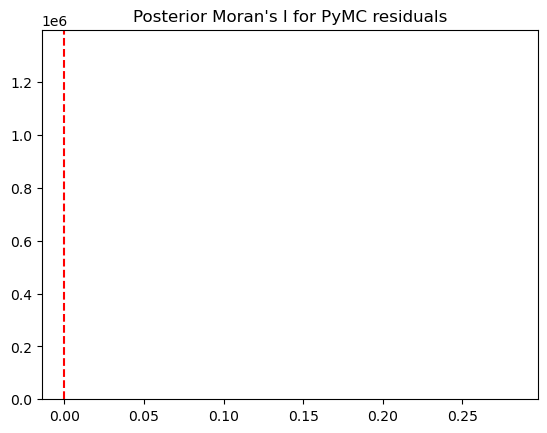

In [7]:
plt.hist(moran_I, bins=40, density=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Posterior Moran's I for PyMC residuals")
plt.show()

In [8]:
trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 12-08/vulcan-tran_div-pie.nc")
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)
az.summary({"moran_I": moran_I})

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
moran_I,0.283,0.0,0.283,0.283,0.0,0.0,4427.0,13.0,NaN


In [9]:
trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 12-08/vulcan-tran_des-pie.nc")
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)
az.summary({"moran_I": moran_I})

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
moran_I,0.283,0.0,0.283,0.283,0.0,0.0,4777.0,14.0,NaN


In [8]:
trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 02-22-2026/vulcan-tran_dist-pie.nc")
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)
az.summary({"moran_I": moran_I})

NameError: name 'ghg_var' is not defined

In [11]:
trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 12-08/vulcan-tran_dest-pie.nc")
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)
az.summary({"moran_I": moran_I})

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
moran_I,0.283,0.0,0.283,0.283,0.0,0.0,4135.0,14.0,NaN


# Electricity

In [3]:
elec_par_file = '/work/hawkins_lab/vulcan/data/vulcan/parquet/vulcan_SC2_epa_climate.parquet'
df = gpd.read_parquet(elec_par_file)
df = df[(df["res_tc"]>0) & (df["totpop"]>0)]

w = Queen.from_dataframe(df)
w.transform = 'r'

trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 02-22-2026/vulcan-elec_dens-pie.nc")

/tmp/ipykernel_485869/749509300.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(df)
/home/jfhawkin/software/miniforge3/envs/pymc_env/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 34 disconnected components.
 There are 11 islands with ids: 3883, 85955, 91075, 95971, 98005, 127428, 135701, 138599, 140953, 151571, 173687.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 3883, ' is an island (no neighbors)')
('WARNING: ', 85955, ' is an island (no neighbors)')
('WARNING: ', 91075, ' is an island (no neighbors)')
('WARNING: ', 95971, ' is an island (no neighbors)')
('WARNING: ', 98005, ' is an island (no neighbors)')
('WARNING: ', 127428, ' is an island (no neighbors)')
('WARNING: ', 135701, ' is an island (no neighbors)')
('WARNING: ', 138599, ' is an island (no neighbors)')
('WARNING: ', 140953, ' is an island (no neighbors)')
('WARNING: ', 151571, ' is an island (no neighbors)')
('WARNING: ', 173687, ' is an island (no neighbors)')


In [4]:
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w, ghg_var="res_tc")
az.summary({"moran_I": moran_I})

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
moran_I,0.466,0.0,0.466,0.466,0.0,0.0,7.0,13.0,NaN


In [5]:
trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 02-22-2026/vulcan-elec_div-pie.nc")
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)
az.summary({"moran_I": moran_I})

KeyError: 'value_weig'

# Residential Energy

In [3]:
res_par_file = '/work/hawkins_lab/vulcan/data/vulcan/parquet/vulcan_RES_epa_climate.parquet'
df = gpd.read_parquet(res_par_file)
df = df[(df["value_weig"]>0) & (df["totpop"]>0)]

w = Queen.from_dataframe(df)
w.transform = 'r'

trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 12-08/vulcan-res_dens-pie.nc")

/tmp/ipykernel_3035993/3036032419.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(df)
/home/jfhawkin/software/miniforge3/envs/pymc_env/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 11 islands with ids: 18612, 32704, 84580, 89701, 94598, 96633, 134310, 137205, 150177, 172293, 207355.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 18612, ' is an island (no neighbors)')
('WARNING: ', 32704, ' is an island (no neighbors)')
('WARNING: ', 84580, ' is an island (no neighbors)')
('WARNING: ', 89701, ' is an island (no neighbors)')
('WARNING: ', 94598, ' is an island (no neighbors)')
('WARNING: ', 96633, ' is an island (no neighbors)')
('WARNING: ', 134310, ' is an island (no neighbors)')
('WARNING: ', 137205, ' is an island (no neighbors)')
('WARNING: ', 150177, ' is an island (no neighbors)')
('WARNING: ', 172293, ' is an island (no neighbors)')
('WARNING: ', 207355, ' is an island (no neighbors)')


In [4]:
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)
az.summary({"moran_I": moran_I})

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
moran_I,0.486,0.0,0.486,0.486,0.0,0.0,4.0,14.0,NaN


In [5]:
trace = az.from_netcdf("/work/hawkins_lab/Mehrnoosh/vulcan-results/vulcan-results 12-08/vulcan-res_div-pie.nc")
moran_I = posterior_moran_I_vect(trace, df, value_var="y_hat", w=w)
az.summary({"moran_I": moran_I})

arviz - WARNING - Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
moran_I,0.486,0.0,0.486,0.486,0.0,0.0,12.0,14.0,NaN


In [ ]:
mu = trace.posterior["y_hat"].stack(sample=("chain", "draw")).values
# shape: (n, draws)

# 3. Observed values
y = df["value_weig"].values.reshape(-1, 1)

# 4. Posterior residuals
residuals = y - mu  # (n, draws)

mi = Moran(residuals[:, d], w)
mi.I